In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mne

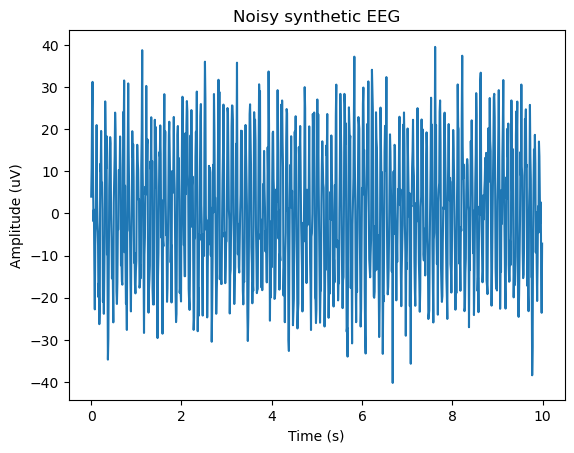

In [2]:
sfreq = 100  # sampling frequency, 100 Hz
times = np.arange(1000) / sfreq  # 10 sekundi

# čist 10 Hz signal, amplituda 20 mikrovolti
signal = 20e-6 * np.sin(2 * np.pi * 10 * times)

# slučajni šum, oko 8 mikrovolti
rng = np.random.RandomState(42)
noise = 8e-6 * rng.randn(len(times))

# finalni signal
data_1d = signal + noise
data = data_1d[None, :]  # MNE očekuje shape = (n_channels, n_times)

plt.plot(times, data_1d * 1e6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (uV)")
plt.title("Noisy synthetic EEG")
plt.show()

In [3]:
info = mne.create_info(
    ch_names=["EEG 001"],
    sfreq=sfreq,
    ch_types=["eeg"]
)

raw = mne.io.RawArray(data, info)
print(raw)

Creating RawArray with float64 data, n_channels=1, n_times=1000
    Range : 0 ... 999 =      0.000 ...     9.990 secs
Ready.
<RawArray | 1 x 1000 (10.0 s), ~13 KiB, data loaded>


In [4]:
raw.plot(scalings={"eeg": 40e-6}, duration=5)

Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x2105f817310) at 0x000002106170D900>

In [5]:
raw_filt = raw.copy().filter(l_freq=1.0, h_freq=20.0)
print(raw_filt)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 331 samples (3.310 s)

<RawArray | 1 x 1000 (10.0 s), ~13 KiB, data loaded>


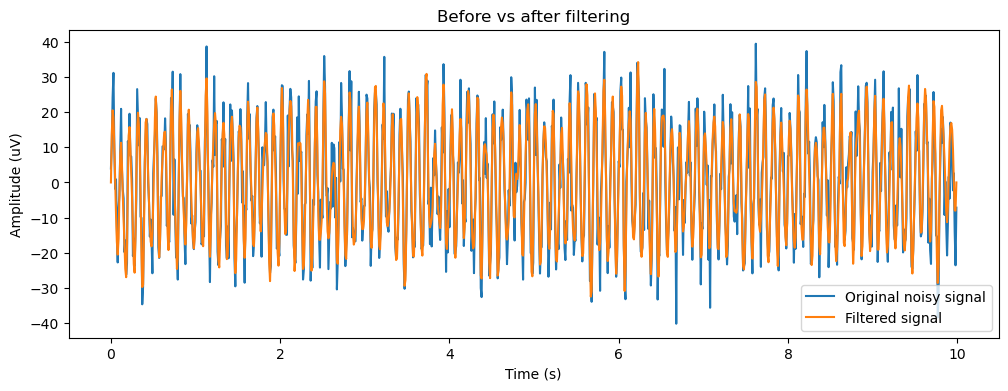

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(times, raw.get_data()[0] * 1e6, label="Original noisy signal")
plt.plot(times, raw_filt.get_data()[0] * 1e6, label="Filtered signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (uV)")
plt.title("Before vs after filtering")
plt.legend()
plt.show()

In [7]:
raw_filt.plot(scalings={"eeg": 40e-6}, duration=5)

<mne_qt_browser._pg_figure.MNEQtBrowser(0x2105df766a0) at 0x00000210660BE680>